In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr
from lmfit import Parameters, minimize
from psyduck.operations import get_spin_operators, quadrupole_hamiltonian

In [2]:
Ix, Iy, Iz = get_spin_operators(7/2)

# Physical constants for Sb-123
Q_N = -0.69e-28    # Nuclear quadrupole moment (C·m²)
I_SPIN = 7/2
GAMMA_NUCLEAR = 5.55  # Nuclear Zeeman splitting (MHz/T)

In [3]:
ds24 = xr.load_dataset('analyzed_data_24.nc', engine='h5netcdf')
ds24['NMR_frequency'] = (('theta', 'NMR_index'), np.array(ds24['NMR_frequency'])[:, ::-1])

thetas = np.linspace(0, np.pi, 9)
fq1_measured = np.array(ds24['NMR_frequency'].diff(dim='NMR_index').mean(dim='NMR_index')) * 1e-6
fq2_measured = np.array(ds24['NMR_frequency'].diff(dim='NMR_index').diff(dim='NMR_index').mean(dim='NMR_index')) * 1e-6

In [4]:
def make_V_ab(Vxx, Vyy, Vzz, Vxy, Vyz, Vxz):
    return np.array([[Vxx, Vxy, Vxz], [Vxy, Vyy, Vyz], [Vxz, Vyz, Vzz]]) * 1e19

def ionized_hamiltonian(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz):
    V_ab = make_V_ab(Vxx, Vyy, Vzz, Vxy, Vyz, Vxz)
    H_q = quadrupole_hamiltonian(I_SPIN, V_ab, Q_N) / 1e6  # Hz → MHz
    H_zeeman = -GAMMA_NUCLEAR * (Iz * np.cos(theta) + Ix * np.sin(theta))
    return H_zeeman + H_q

In [5]:
def residual(params):
    p = params.valuesdict()
    fq1_arr = np.zeros(len(thetas))
    fq2_arr = np.zeros(len(thetas))
    for t, theta in enumerate(thetas):
        evals = ionized_hamiltonian(theta, **p).eigenstates()[0]
        fq1_arr[t] = np.mean(np.diff(np.diff(evals)))
        fq2_arr[t] = np.mean(np.diff(np.diff(np.diff(evals))))
    return np.vstack([
        (fq1_arr - fq1_measured) / np.max(fq1_measured),
        (fq2_arr - fq2_measured) / np.max(fq2_measured),
    ])

params = Parameters()
params.add('Vxx', value=-4, min=-5,  max=5)
params.add('Vyy', value=1,  min=-5,  max=5)
params.add('Vzz', expr='- Vxx - Vyy')
params.add('Vxy', value=0,  min=-20, max=20)
params.add('Vyz', value=0,  min=-5,  max=20)
params.add('Vxz', value=0,  min=-5,  max=20)

result = minimize(residual, params, method='leastsq')
result.params.pretty_print()

Name     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Vxx     2.664       -5        5  0.04413     True     None     None
Vxy     7.683      -20       20  0.08671     True     None     None
Vxz   -0.6561       -5       20   0.0365     True     None     None
Vyy    -0.772       -5        5  0.04948     True     None     None
Vyz    -1.297       -5       20    0.115     True     None     None
Vzz    -1.892     -inf      inf  0.03812    False - Vxx - Vyy     None


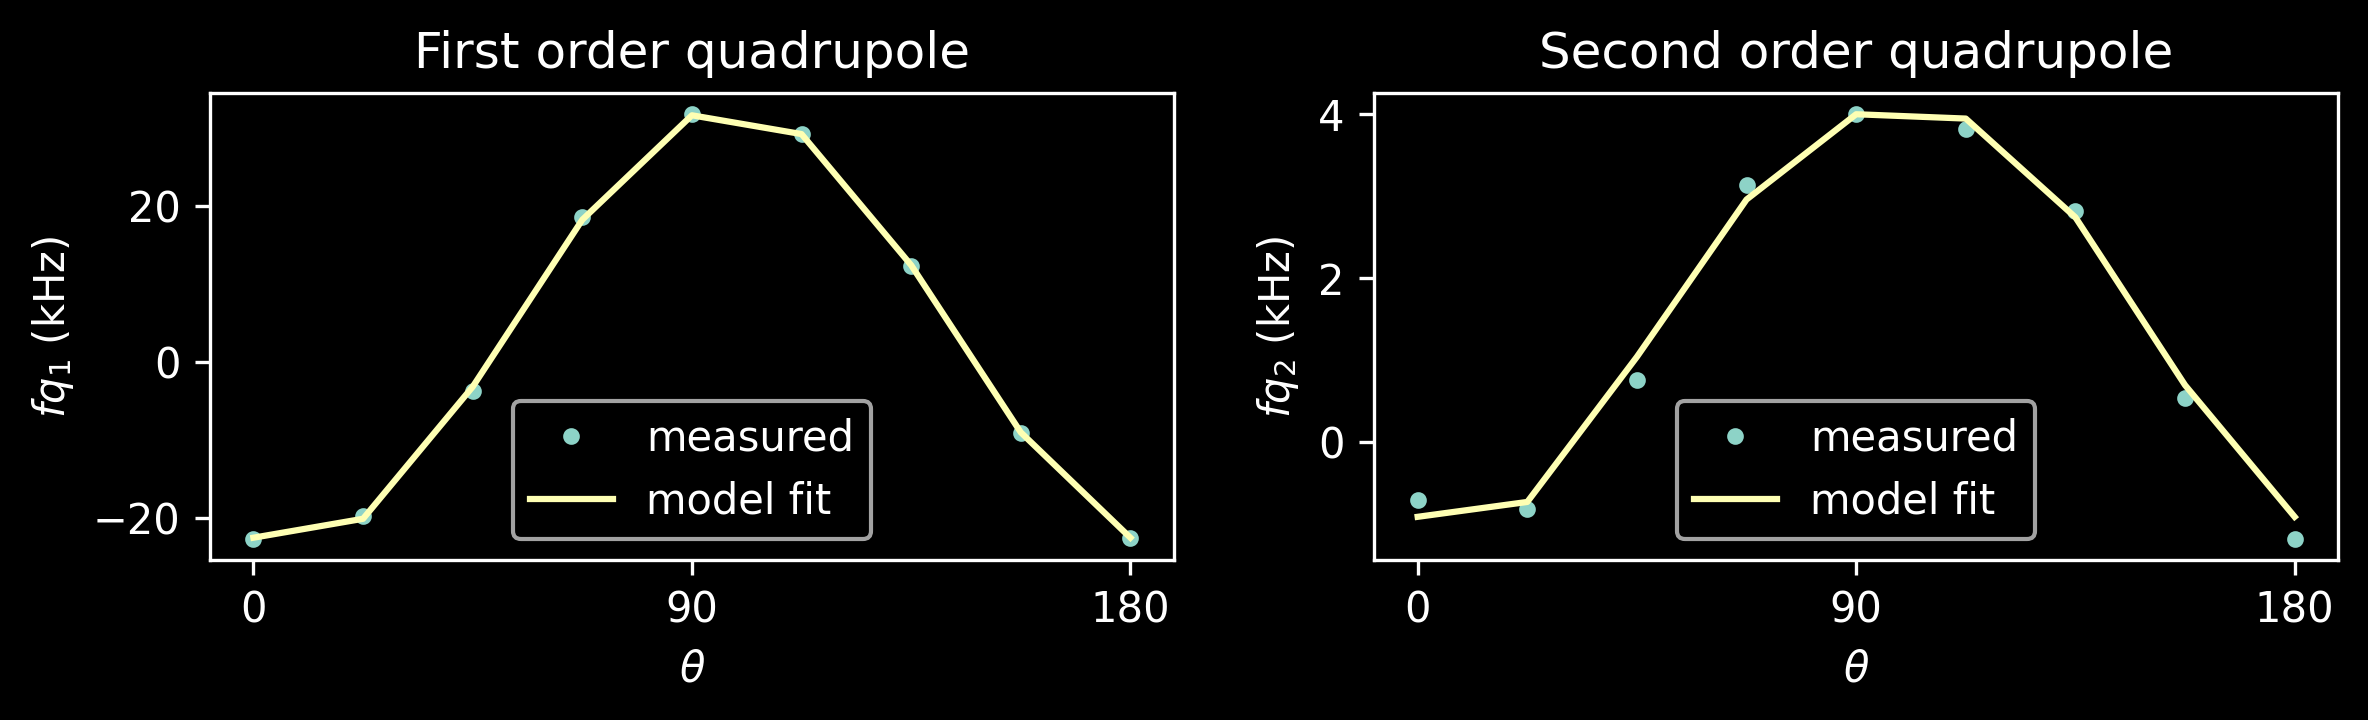

In [6]:
p = result.params.valuesdict()
fq1_arr = np.zeros(len(thetas))
fq2_arr = np.zeros(len(thetas))
for t, theta in enumerate(thetas):
    evals = ionized_hamiltonian(theta, **p).eigenstates()[0]
    fq1_arr[t] = np.mean(np.diff(np.diff(evals)))
    fq2_arr[t] = np.mean(np.diff(np.diff(np.diff(evals))))

fig, ax = plt.subplots(1, 2, figsize=(8, 2.5), dpi=300)
ax[0].plot(thetas / np.pi * 180, -fq1_measured * 1e3, '.', label='measured')
ax[0].plot(thetas / np.pi * 180, -fq1_arr * 1e3, label='model fit')
ax[1].plot(thetas / np.pi * 180, fq2_measured * 1e3, '.', label='measured')
ax[1].plot(thetas / np.pi * 180, fq2_arr * 1e3, label='model fit')
for a, title, ylabel in zip(ax,
        ['First order quadrupole', 'Second order quadrupole'],
        ['$fq_1$ (kHz)', '$fq_2$ (kHz)']):
    a.legend()
    a.set_title(title)
    a.set_ylabel(ylabel)
    a.set_xlabel(r'$\theta$')
    a.set_xticks([0, 90, 180])
plt.tight_layout()

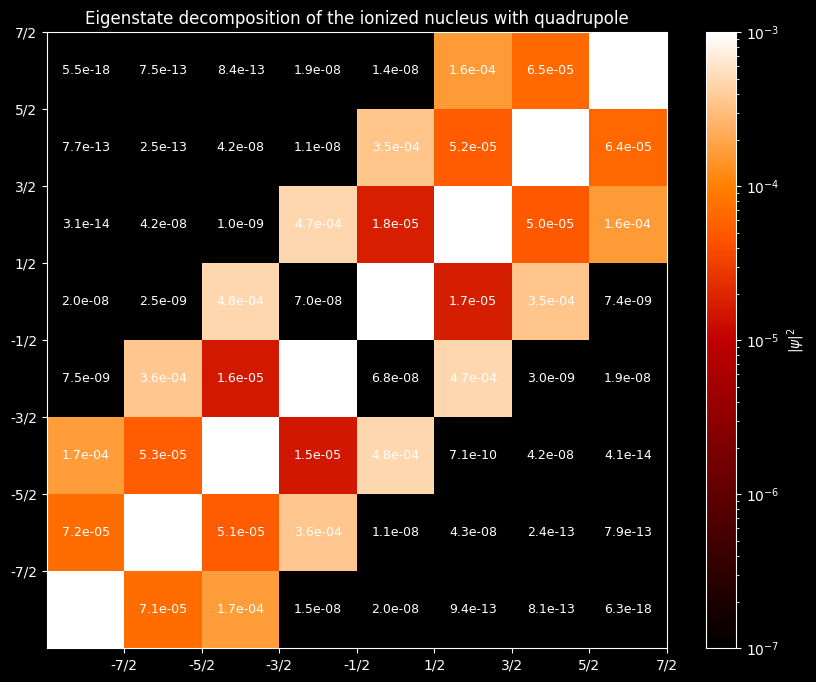

In [9]:
H_ionized = ionized_hamiltonian(0, **result.params.valuesdict())
evals, evecs = H_ionized.eigenstates()

evec_matrix = np.array([v.full().flatten() for v in evecs])
Z = np.abs(evec_matrix) ** 2
Z[Z == 0] = 1e-7

nucleus_labels = ["-7/2", "-5/2", "-3/2", "-1/2", "1/2", "3/2", "5/2", "7/2"]

fig, ax = plt.subplots(figsize=(10, 8))
pcm = ax.pcolormesh(np.arange(8), np.arange(8), Z,
                    norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-3), cmap="gist_heat")
for i in range(8):
    for j in range(8):
        ax.text(j, i, f"{Z[i, j]:.1e}",
                color="white", ha="center", va="center", fontsize=9)
ax.set_xticks(np.arange(8) + 0.5)
ax.set_yticks(np.arange(8) + 0.5)
ax.set_xticklabels(nucleus_labels)
ax.set_yticklabels(nucleus_labels)
ax.set_title('Eigenstate decomposition of the ionized nucleus with quadrupole')
plt.colorbar(pcm, label=r'$|\psi|^2$')
plt.show()

In [10]:
V_ab = make_V_ab(**result.params.valuesdict())
H_quad_fit = quadrupole_hamiltonian(I_SPIN, V_ab, Q_N) / 1e6  # MHz
np.save('H_quad_fit.npy', H_quad_fit.full())